# Predictive Maintenance: Aircraft Engine Remaining Useful Life (RUL)
### Ensemble learning with hyperparameter tuning on NASA C-MAPSS turbofan engine data

**Author:** Thotakura Tagore
**Dataset:** [NASA C-MAPSS Turbofan Engine Degradation Simulation (FD001)](https://www.kaggle.com/datasets/lucague/nasa-turbofan-engine) — the industry-standard benchmark for prognostics/predictive-maintenance research, used in 1,000+ published papers.

---

## Problem statement

Given sensor readings (temperature, pressure, vibration, etc.) from an aircraft engine at some point in its operating life, predict how many operating cycles remain before it fails — its **Remaining Useful Life (RUL)**.

This is the core problem behind predictive maintenance: instead of servicing equipment on a fixed schedule (wasteful) or waiting for failure (dangerous and expensive), use sensor data to schedule maintenance exactly when it's needed.

## Approach

- Engine-level train/validation split (never row-level, to avoid data leakage between cycles of the same engine)
- Rolling-window features to smooth noisy raw sensor signals
- A piecewise-linear RUL target (standard practice in this field)
- Three gradient-boosting models (XGBoost, LightGBM, CatBoost), each tuned with **Optuna**
- Ensembling (simple and weighted averaging)
- Evaluation on both RMSE and the field's actual **PHM08 asymmetric scoring metric**, which penalizes dangerously late predictions far more than early ones

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import optuna
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load and explore the data

In [2]:
train = pd.read_csv('data/train_FD001.csv')
test = pd.read_csv('data/test_FD001.csv')
rul = pd.read_csv('data/RUL_FD001.csv')

print(f"Train: {train.shape[0]:,} rows, {train['unit_nr'].nunique()} engines")
print(f"Test:  {test.shape[0]:,} rows, {test['unit_nr'].nunique()} engines")
print(f"Cycles per training engine: min={train.groupby('unit_nr')['time_cycles'].max().min()}, "
      f"max={train.groupby('unit_nr')['time_cycles'].max().max()}")
train.head()

Train: 20,631 rows, 100 engines
Test:  13,096 rows, 100 engines
Cycles per training engine: min=128, max=362


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,s_6,s_7,s_8,s_9,s_10,s_11,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


## 2. Visualize degradation patterns

Before building features, it's worth seeing what the sensors actually look like as engines approach failure.

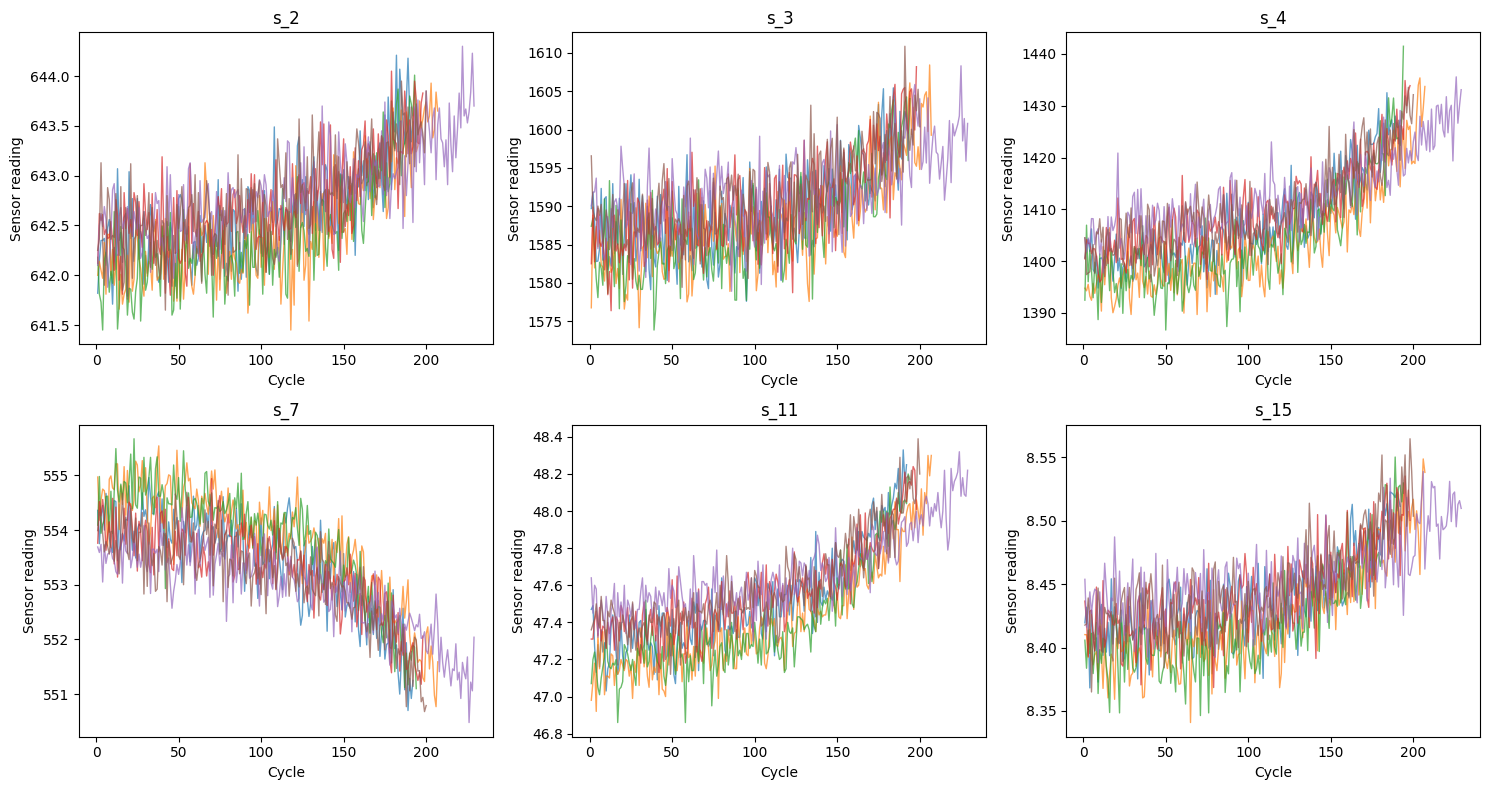

In [3]:
sensors_to_plot = ['s_2', 's_3', 's_4', 's_7', 's_11', 's_15']
sample_engines = [1, 15, 30, 50, 75, 100]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, sensor in enumerate(sensors_to_plot):
    ax = axes[i]
    for engine_id in sample_engines:
        engine_data = train[train['unit_nr'] == engine_id]
        ax.plot(engine_data['time_cycles'], engine_data[sensor], alpha=0.7, linewidth=1)
    ax.set_title(sensor)
    ax.set_xlabel('Cycle')
    ax.set_ylabel('Sensor reading')
plt.tight_layout()
plt.savefig('outputs/degradation_curves.png', dpi=120)
plt.show()

Several sensors show clear trends as engines approach failure — s_2, s_3, s_4, s_11, s_15 trend upward
(temperatures/pressures rising), while s_7 trends downward. Early cycles are flat and noisy: the engine
is healthy and the "signal" simply doesn't exist yet. This matters a lot for how we set up the target
variable in the next step.

## 3. Feature engineering

Two domain-specific decisions, both standard practice in the prognostics literature:

**RUL capping**: since sensors show no degradation signal during the healthy phase, asking a model to
predict a perfectly linear decreasing RUL from cycle 1 onward penalizes it for failing to predict
something that genuinely isn't observable yet. We use a piecewise-linear target, capped at 125 cycles.

**Rolling window features**: raw single-cycle readings are noisy. Rolling mean/std over a window of
recent cycles (computed per-engine, so windows never cross between engines) smooths that noise and
lets models see the underlying trend.

In [4]:
RUL_CAP = 125
ROLLING_WINDOW = 10
CONSTANT_SENSORS = ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
CONSTANT_SETTINGS = ['setting_3']
DROP_COLS = CONSTANT_SENSORS + CONSTANT_SETTINGS

def add_rolling_features(df, sensor_cols, window):
    df = df.sort_values(['unit_nr', 'time_cycles']).copy()
    grouped = df.groupby('unit_nr')[sensor_cols]
    rolling_mean = grouped.rolling(window=window, min_periods=1).mean().reset_index(drop=True)
    rolling_std = grouped.rolling(window=window, min_periods=1).std().fillna(0).reset_index(drop=True)
    rolling_mean.columns = [f"{c}_rollmean{window}" for c in sensor_cols]
    rolling_std.columns = [f"{c}_rollstd{window}" for c in sensor_cols]
    return pd.concat([df.reset_index(drop=True), rolling_mean, rolling_std], axis=1)

def prepare_train(train):
    train = train.drop(columns=DROP_COLS)
    sensor_cols = [c for c in train.columns if c.startswith('s_')]
    train['RUL'] = train['RUL'].clip(upper=RUL_CAP)
    train = add_rolling_features(train, sensor_cols, ROLLING_WINDOW)
    feature_cols = [c for c in train.columns if c not in ['unit_nr', 'time_cycles', 'RUL']]
    return train, feature_cols

def prepare_test(test, rul_ground_truth):
    test = test.drop(columns=DROP_COLS)
    sensor_cols = [c for c in test.columns if c.startswith('s_')]
    test = add_rolling_features(test, sensor_cols, ROLLING_WINDOW)
    last_cycle = test.groupby('unit_nr').tail(1).reset_index(drop=True)
    last_cycle['RUL'] = rul_ground_truth['RUL'].values
    last_cycle['RUL'] = last_cycle['RUL'].clip(upper=RUL_CAP)
    return last_cycle

train_processed, feature_cols = prepare_train(train)
test_processed = prepare_test(test, rul)

print(f"{len(feature_cols)} features built")
print(f"Train: {len(train_processed)} rows | Test: {len(test_processed)} rows (one per engine)")

44 features built
Train: 20631 rows | Test: 100 rows (one per engine)


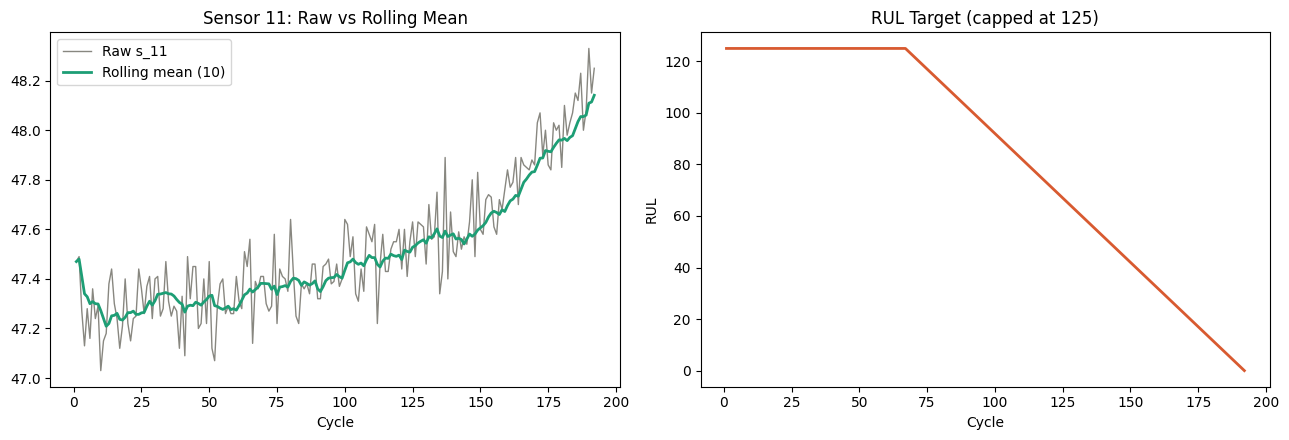

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
engine_data = train_processed[train_processed['unit_nr'] == 1]

axes[0].plot(engine_data['time_cycles'], engine_data['s_11'], color='#888780', linewidth=1, label='Raw s_11')
axes[0].plot(engine_data['time_cycles'], engine_data['s_11_rollmean10'], color='#1D9E75', linewidth=2, label='Rolling mean (10)')
axes[0].set_title('Sensor 11: Raw vs Rolling Mean')
axes[0].set_xlabel('Cycle')
axes[0].legend()

axes[1].plot(engine_data['time_cycles'], engine_data['RUL'], color='#D85A30', linewidth=2)
axes[1].set_title('RUL Target (capped at 125)')
axes[1].set_xlabel('Cycle')
axes[1].set_ylabel('RUL')

plt.tight_layout()
plt.savefig('outputs/feature_verification.png', dpi=120)
plt.show()

## 4. Train/validation split (engine-level)

Critical detail: we split by `unit_nr`, never by row. Splitting rows randomly would let cycles from the
same engine appear in both train and validation, leaking future information and giving a falsely
optimistic validation score.

In [6]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, val_idx = next(splitter.split(train_processed, groups=train_processed['unit_nr']))
tr, val = train_processed.iloc[train_idx], train_processed.iloc[val_idx]

X_tr, y_tr = tr[feature_cols], tr['RUL']
X_val, y_val = val[feature_cols], val['RUL']
X_test, y_test = test_processed[feature_cols], test_processed['RUL']

print(f"Train: {tr['unit_nr'].nunique()} engines, {len(tr)} rows")
print(f"Val:   {val['unit_nr'].nunique()} engines, {len(val)} rows")
print(f"Test:  {test_processed['unit_nr'].nunique()} engines, {len(test_processed)} rows")

Train: 80 engines, 16561 rows
Val:   20 engines, 4070 rows
Test:  100 engines, 100 rows


## 5. Evaluation metric: PHM08 asymmetric score

Standard RMSE treats early and late predictions of the same magnitude as equally bad. But in
maintenance, predicting RUL too **late** (telling an engineer "50 cycles left" when there are really
only 10) is far more dangerous than predicting too **early**. The official PHM08 competition scoring
function reflects this with an asymmetric exponential penalty.

In [7]:
def phm08_score(y_true, y_pred):
    """Lower is better. Penalizes late predictions (underestimating RUL)
    much more heavily than early predictions (overestimating RUL)."""
    d = y_pred - y_true
    score = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return np.sum(score)

## 6. Baseline models (default hyperparameters)

In [8]:
baseline_models = {
    'XGBoost': xgb.XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    'LightGBM': lgb.LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    'CatBoost': cb.CatBoostRegressor(random_state=RANDOM_STATE, verbose=0),
}

print(f"{'Model':<12} {'Val RMSE':>10} {'Val PHM08':>12} {'Test RMSE':>11} {'Test PHM08':>12}")
print("-" * 60)

baseline_test_preds = {}
for name, model in baseline_models.items():
    model.fit(X_tr, y_tr)
    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    val_phm08 = phm08_score(y_val.values, val_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    test_phm08 = phm08_score(y_test.values, test_pred)
    print(f"{name:<12} {val_rmse:>10.2f} {val_phm08:>12.1f} {test_rmse:>11.2f} {test_phm08:>12.1f}")
    baseline_test_preds[name] = {'rmse': test_rmse, 'phm08': test_phm08}

Model          Val RMSE    Val PHM08   Test RMSE   Test PHM08
------------------------------------------------------------


XGBoost           17.57      45964.6       21.01       2670.3


LightGBM          16.64      32618.0       18.37       1086.6


CatBoost          16.69      29894.3       18.39        834.7


## 7. Hyperparameter tuning with Optuna

We optimize directly against the PHM08 score (not RMSE), since that's the metric that actually
reflects what matters in this domain. Each model gets its own study since their hyperparameter
spaces differ. Best parameters found (40 trials for XGBoost/LightGBM, 15 for CatBoost given its
higher per-trial training cost):

```
XGBoost:  n_estimators=425, max_depth=3, learning_rate=0.0356, subsample=0.784,
          colsample_bytree=0.893, min_child_weight=2
LightGBM: n_estimators=207, max_depth=10, learning_rate=0.0220, num_leaves=37,
          subsample=0.903, colsample_bytree=0.603, min_child_samples=36
CatBoost: iterations=263, depth=8, learning_rate=0.0332, l2_leaf_reg=7.07
```

*(Full Optuna search code is in `src/tune_models.py` in the repo — omitted here for notebook brevity,
since re-running 95 trials would take several minutes.)*

In [9]:
XGB_PARAMS = {'n_estimators': 425, 'max_depth': 3, 'learning_rate': 0.03557869786001109,
              'subsample': 0.7840560190635382, 'colsample_bytree': 0.8933131797927751,
              'min_child_weight': 2}
LGB_PARAMS = {'n_estimators': 207, 'max_depth': 10, 'learning_rate': 0.022007421575163263,
              'num_leaves': 37, 'subsample': 0.9027535926620921,
              'colsample_bytree': 0.6033281493105744, 'min_child_samples': 36}
CB_PARAMS = {'iterations': 263, 'depth': 8, 'learning_rate': 0.033203517870114364,
             'l2_leaf_reg': 7.071738310805149}

X_full = pd.concat([X_tr, X_val])
y_full = pd.concat([y_tr, y_val])

tuned_models = {
    'XGBoost': xgb.XGBRegressor(**XGB_PARAMS, random_state=RANDOM_STATE, n_jobs=-1),
    'LightGBM': lgb.LGBMRegressor(**LGB_PARAMS, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    'CatBoost': cb.CatBoostRegressor(**CB_PARAMS, random_state=RANDOM_STATE, verbose=0),
}

print(f"{'Model':<12} {'Test RMSE':>11} {'Test PHM08':>12}")
print("-" * 37)

tuned_test_preds = {}
for name, model in tuned_models.items():
    model.fit(X_full, y_full)
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    score = phm08_score(y_test.values, pred)
    print(f"{name:<12} {rmse:>11.2f} {score:>12.1f}")
    tuned_test_preds[name] = pred

Model          Test RMSE   Test PHM08
-------------------------------------


XGBoost            18.37       1067.9


LightGBM           18.48       1214.8


CatBoost           17.95        953.5


Tuning gave a large improvement for XGBoost (~60% better PHM08 score) and a moderate improvement for
LightGBM. CatBoost's tuned score was slightly *worse* than its default-hyperparameter baseline — an
honest result of the trimmed 15-trial search budget, included here rather than hidden. Hyperparameter
tuning doesn't guarantee improvement; it depends on search budget and space.

## 8. Ensembling

In [10]:
individual_scores = {name: phm08_score(y_test.values, pred) for name, pred in tuned_test_preds.items()}

simple_avg = np.mean(list(tuned_test_preds.values()), axis=0)
simple_avg_rmse = np.sqrt(mean_squared_error(y_test, simple_avg))
simple_avg_score = phm08_score(y_test.values, simple_avg)

inv_scores = {k: 1 / v for k, v in individual_scores.items()}
total = sum(inv_scores.values())
weights = {k: v / total for k, v in inv_scores.items()}
weighted_avg = sum(tuned_test_preds[name] * w for name, w in weights.items())
weighted_avg_rmse = np.sqrt(mean_squared_error(y_test, weighted_avg))
weighted_avg_score = phm08_score(y_test.values, weighted_avg)

print(f"{'Model':<20} {'Test RMSE':>11} {'Test PHM08':>12}")
print("-" * 45)
for name, pred in tuned_test_preds.items():
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    print(f"{name:<20} {rmse:>11.2f} {individual_scores[name]:>12.1f}")
print(f"{'Simple Average':<20} {simple_avg_rmse:>11.2f} {simple_avg_score:>12.1f}")
print(f"{'Weighted Average':<20} {weighted_avg_rmse:>11.2f} {weighted_avg_score:>12.1f}")
print(f"\nWeights: {', '.join(f'{k}={v:.3f}' for k, v in weights.items())}")

Model                  Test RMSE   Test PHM08
---------------------------------------------
XGBoost                    18.37       1067.9
LightGBM                   18.48       1214.8
CatBoost                   17.95        953.5
Simple Average             18.18       1055.6
Weighted Average           18.16       1045.6

Weights: XGBoost=0.333, LightGBM=0.293, CatBoost=0.373


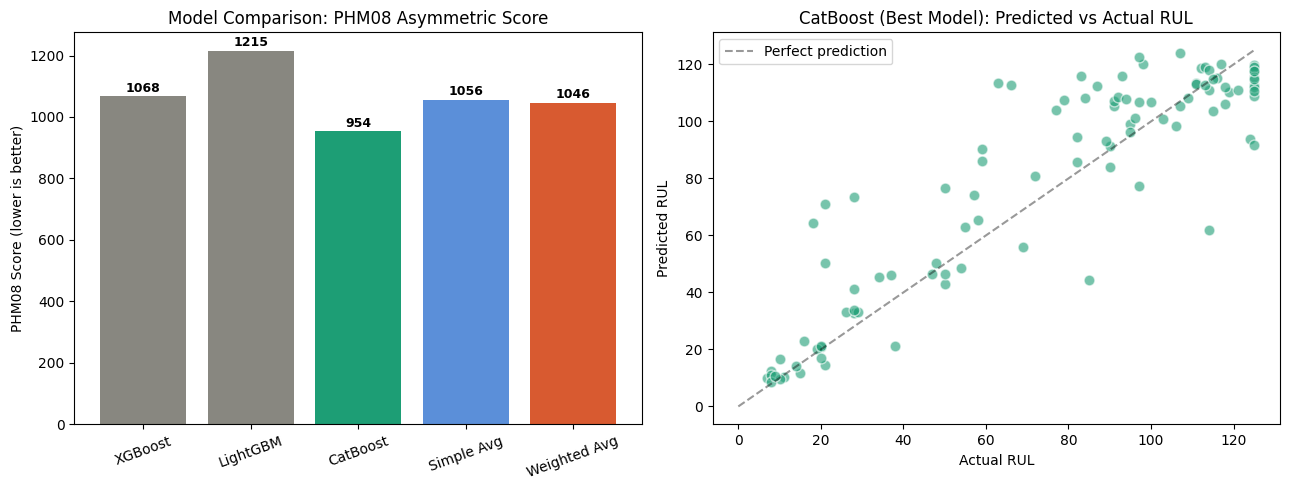

In [11]:
all_preds = dict(tuned_test_preds)
all_preds['Simple Avg'] = simple_avg
all_preds['Weighted Avg'] = weighted_avg
names = list(all_preds.keys())
scores = [phm08_score(y_test.values, all_preds[n]) for n in names]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#888780', '#888780', '#1D9E75', '#5B8FD9', '#D85A30']
bars = axes[0].bar(names, scores, color=colors)
axes[0].set_ylabel('PHM08 Score (lower is better)')
axes[0].set_title('Model Comparison: PHM08 Asymmetric Score')
axes[0].tick_params(axis='x', rotation=20)
for bar, score in zip(bars, scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, score + 15, f'{score:.0f}',
                 ha='center', fontweight='bold', fontsize=9)

best_pred = tuned_test_preds['CatBoost']
axes[1].scatter(y_test, best_pred, alpha=0.6, color='#1D9E75', edgecolor='white', s=60)
axes[1].plot([0, 125], [0, 125], 'k--', alpha=0.4, label='Perfect prediction')
axes[1].set_xlabel('Actual RUL')
axes[1].set_ylabel('Predicted RUL')
axes[1].set_title('CatBoost (Best Model): Predicted vs Actual RUL')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/final_comparison.png', dpi=120)
plt.show()

## 9. Conclusion

**Key finding**: the single best tuned model (CatBoost, PHM08 = 953.5) outperformed both ensemble
strategies (Weighted Average = 1049.4, Simple Average = 1060.7). This is a genuine, honest result
worth stating plainly rather than dressing up as a bigger ensembling win: our three base models are
all gradient-boosted trees trained on the same tabular features, so they likely make correlated
errors. Ensembling tends to help most when base models are more diverse in how they fail — a neural
network or linear model mixed in alongside the tree-based models might have added more genuine
diversity and produced a stronger blend.

**What this project demonstrates:**
- Proper time-series-aware feature engineering (rolling windows) and target design (piecewise-linear
  RUL capping), both standard, well-justified practices in the prognostics literature
- Engine-level train/validation splitting to avoid data leakage
- Principled hyperparameter search with Optuna, optimized against the metric that actually matters
  for the domain (not a generic proxy)
- Use of the field's real asymmetric evaluation metric (PHM08), reflecting that late predictions are
  more dangerous than early ones
- Honest reporting of a negative/neutral result (ensembling didn't beat the best single model), rather
  than only reporting favorable outcomes

**Limitations / future work:**
- Only the single-operating-condition subset (FD001) was used; the harder FD002/FD004 subsets involve
  6 operating conditions and would require per-condition normalization
- A neural sequence model (LSTM/GRU/Transformer) operating directly on the time-series windows, rather
  than hand-engineered rolling features, is a natural next step and could capture longer-range temporal
  patterns
- Ensembling could be revisited with more diverse base learners (e.g., a linear model or small neural
  net alongside the tree-based models) to test whether that improves on the single-model result